In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


In [4]:
df=pd.read_csv(r"C:\Users\Spandan\Downloads\AI Analyser\Demo\student_academic_placement_performance_dataset.csv")

In [5]:
print(df.head())

   student_id  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0           1    Male              53              79                 56   
1           2  Female              56              54                 59   
2           3    Male              94              83                 83   
3           4    Male              84              71                 87   
4           5    Male              58              88                 74   

   cgpa  entrance_exam_score  technical_skill_score  soft_skill_score  \
0  8.87                   50                     92                90   
1  6.78                   61                     51                99   
2  7.92                   91                     93                84   
3  6.57                   85                     60                72   
4  9.01                   73                     52                88   

   internship_count  live_projects  work_experience_months  certifications  \
0                 1       

In [6]:
print(df.tail())

      student_id  gender  ssc_percentage  hsc_percentage  degree_percentage  \
4995        4996    Male              68              50                 67   
4996        4997  Female              61              52                 56   
4997        4998    Male              74              76                 58   
4998        4999  Female              84              67                 66   
4999        5000  Female              61              79                 64   

      cgpa  entrance_exam_score  technical_skill_score  soft_skill_score  \
4995  8.32                   51                     57                96   
4996  9.47                   61                     59                62   
4997  6.19                   40                     99                89   
4998  8.07                   40                     48                92   
4999  6.97                   42                     80                59   

      internship_count  live_projects  work_experience_months  certi

In [7]:
print(df.shape)

(5000, 18)


In [8]:
print(df.columns)

Index(['student_id', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'cgpa', 'entrance_exam_score',
       'technical_skill_score', 'soft_skill_score', 'internship_count',
       'live_projects', 'work_experience_months', 'certifications',
       'attendance_percentage', 'backlogs', 'extracurricular_activities',
       'placement_status', 'salary_package_lpa'],
      dtype='object')


In [9]:
print(df.dtypes)

student_id                      int64
gender                         object
ssc_percentage                  int64
hsc_percentage                  int64
degree_percentage               int64
cgpa                          float64
entrance_exam_score             int64
technical_skill_score           int64
soft_skill_score                int64
internship_count                int64
live_projects                   int64
work_experience_months          int64
certifications                float64
attendance_percentage         float64
backlogs                      float64
extracurricular_activities     object
placement_status                int64
salary_package_lpa            float64
dtype: object


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              4998 non-null   float64
 13  attendance_percentage       4999 

In [11]:
print(df.describe())

        student_id  ssc_percentage  hsc_percentage  degree_percentage  \
count  5000.000000     5000.000000     5000.000000        5000.000000   
mean   2500.500000       72.425800       71.910800          71.845200   
std    1443.520003       13.199642       12.842781          10.013196   
min       1.000000       50.000000       50.000000          55.000000   
25%    1250.750000       61.000000       61.000000          63.000000   
50%    2500.500000       72.000000       72.000000          72.000000   
75%    3750.250000       84.000000       83.000000          80.000000   
max    5000.000000       95.000000       94.000000          89.000000   

              cgpa  entrance_exam_score  technical_skill_score  \
count  5000.000000          5000.000000            5000.000000   
mean      7.678326            69.197800              69.651000   
std       1.237084            17.325528              17.179704   
min       5.500000            40.000000              40.000000   
25%       6.

In [12]:
outlier_tuple = {
    "student_id": 9999,                    
    "gender": "Other",                     
    "ssc_percentage": 110.0,               
    "hsc_percentage": 105.0,               
    "degree_percentage": 98.0,           
    "cgpa": 14.8,                          
    "entrance_exam_score": 390,             
    "technical_skill_score": 99,        
    "soft_skill_score": 100,                
    "internship_count": 15,                
    "live_projects": 12,                   
    "work_experience_months": 120,          
    "certifications": 25,                   
    "attendance_percentage": 130.0,      
    "backlogs": 0,
    "extracurricular_activities": 20,       
    "placement_status": 1,
    "salary_package_lpa": 75.0              
}
df = pd.concat([df, pd.DataFrame([outlier_tuple])], ignore_index=True)


In [13]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [14]:
df.isnull().sum()


student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
dtype: int64

In [15]:
bins = [0, 6, 9, float("inf")]
labels = ["Low", "Medium", "High"]

df["cgpa_bin"] = pd.cut(df["cgpa"], bins=bins, labels=labels, right=False)


In [16]:
df["cgpa_bin"].value_counts()


Medium    3467
High       946
Low        588
Name: cgpa_bin, dtype: int64

In [17]:
df.loc[df["cgpa_bin"] == "High", "cgpa"]


4        9.01
6        9.07
14       9.74
47       9.25
51       9.08
        ...  
4979     9.06
4980     9.47
4983     9.35
4996     9.47
5000    14.80
Name: cgpa, Length: 946, dtype: float64

In [18]:
df.loc[df["cgpa_bin"] == "Medium", "cgpa"]


0       8.87
1       6.78
2       7.92
3       6.57
7       8.09
        ... 
4993    8.11
4995    8.32
4997    6.19
4998    8.07
4999    6.97
Name: cgpa, Length: 3467, dtype: float64

In [19]:
df.loc[df["cgpa_bin"] == "Low", "cgpa"]


5       5.98
13      5.77
15      5.64
23      5.99
26      5.62
        ... 
4973    5.96
4974    5.93
4982    5.96
4986    5.66
4994    5.97
Name: cgpa, Length: 588, dtype: float64

In [20]:
from sklearn.preprocessing import MinMaxScaler

scale_columns = [
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage',
    'cgpa',
    'entrance_exam_score',
    'technical_skill_score',
    'soft_skill_score',
    'attendance_percentage',
    'salary_package_lpa'
]
scaler = MinMaxScaler()
df[scale_columns] = scaler.fit_transform(df[scale_columns])


In [21]:
print(df.head())


   student_id  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0           1    Male        0.050000        0.527273           0.023256   
1           2  Female        0.100000        0.072727           0.093023   
2           3    Male        0.733333        0.600000           0.651163   
3           4    Male        0.566667        0.381818           0.744186   
4           5    Male        0.133333        0.690909           0.441860   

       cgpa  entrance_exam_score  technical_skill_score  soft_skill_score  \
0  0.362366             0.028571               0.881356          0.833333   
1  0.137634             0.060000               0.186441          0.983333   
2  0.260215             0.145714               0.898305          0.733333   
3  0.115054             0.128571               0.338983          0.533333   
4  0.377419             0.094286               0.203390          0.800000   

   internship_count  live_projects  work_experience_months  certifications  \
0 

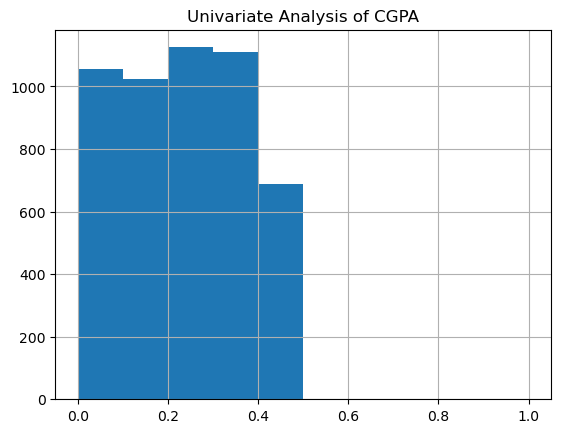

In [22]:
df["cgpa"].hist()
plt.title("Univariate Analysis of CGPA")
plt.show()


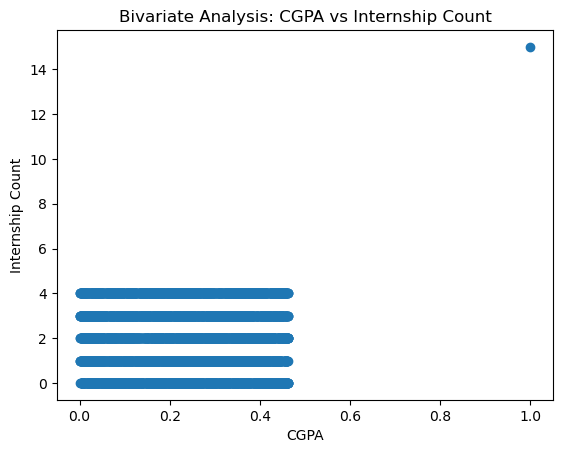

In [24]:
import matplotlib.pyplot as plt

plt.scatter(df["cgpa"], df["internship_count"])
plt.xlabel("CGPA")
plt.ylabel("Internship Count")
plt.title("Bivariate Analysis: CGPA vs Internship Count")
plt.show()


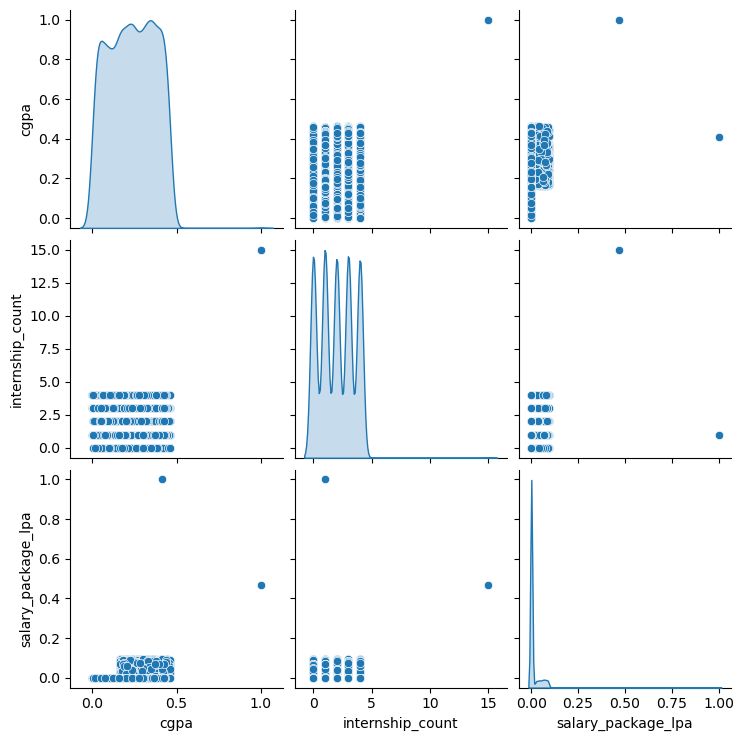

In [25]:
sns.pairplot(df[["cgpa", "internship_count", "salary_package_lpa"]],
             diag_kind="kde")
plt.show()



In [26]:
df_median = df.copy()
df_median["salary_package_lpa"].fillna(
    df_median["salary_package_lpa"].median(),
    inplace=True
)


In [27]:
print("Missing values after imputation:")
print(df["salary_package_lpa"].isnull().sum())


Missing values after imputation:
0


In [32]:
df_no_outliers = df[(df["cgpa"] >= lower_bound) & (df["cgpa"] <= upper_bound)]
df_no_outliers["cgpa"].max()


NameError: name 'lower_bound' is not defined

In [33]:
plt.figure(figsize=(5, 6))
plt.boxplot(df_no_outliers["cgpa"])
plt.title("CGPA Boxplot (After Outlier Removal)")
plt.ylabel("CGPA")
plt.show()



NameError: name 'df_no_outliers' is not defined

<Figure size 500x600 with 0 Axes>

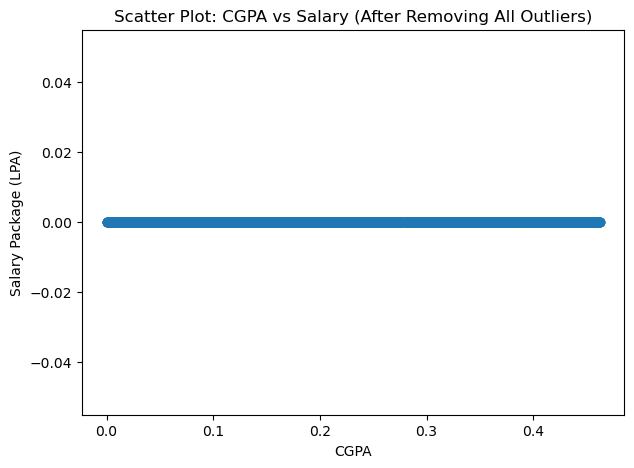

In [41]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["cgpa"],
    df_clean["salary_package_lpa"]
)
plt.xlabel("CGPA")
plt.ylabel("Salary Package (LPA)")
plt.title("Scatter Plot: CGPA vs Salary (After Removing All Outliers)")
plt.show()



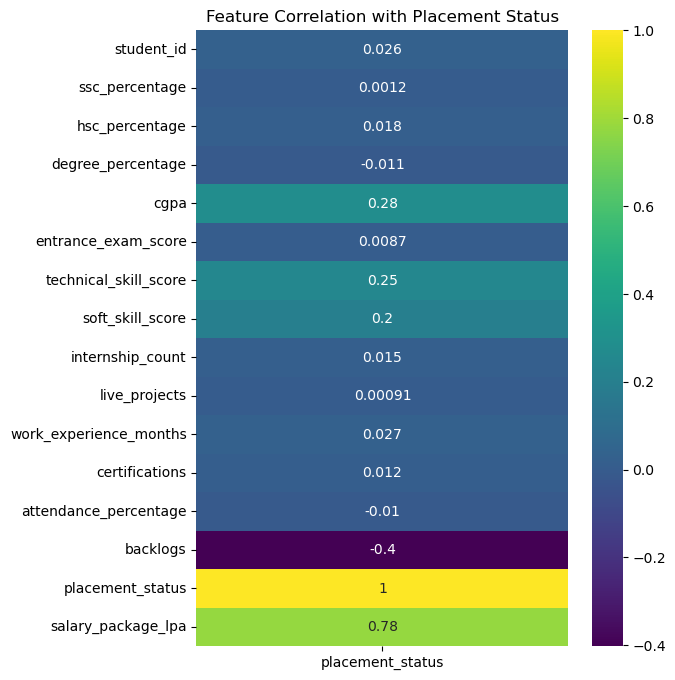

In [30]:
df_encoded = df.copy()

corr_matrix = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_matrix[["placement_status"]],
    annot=True,
    cmap="viridis"
)
plt.title("Feature Correlation with Placement Status")
plt.show()


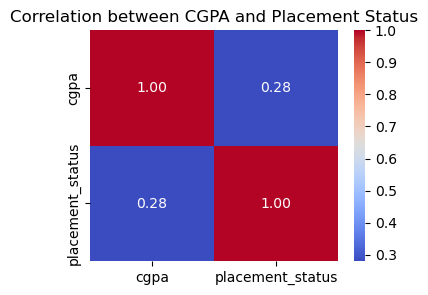

In [31]:
heatmap_df = df[["cgpa", "placement_status"]]
corr = heatmap_df.corr()
plt.figure(figsize=(4, 3))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation between CGPA and Placement Status")
plt.show()